# IND320 – Reservoir data project

This notebook reads the reservoirs.csv dataset, gives the columns understandable English names, and creates separate and combined plots. The Streamlit app in the same repository provides an online version of the exploration.

**GitHub repository:** https://github.com/Yangocito/ind320-reservoir-dashboard-yangocito/tree/main

**Streamlit app:** https://ind320-reservoir-dashboard-yangocito-jqlwog89hlllmliwtrhsmd.streamlit.app/

## 1. Imports and data loading

The CSV is read from the repository's data folder so that the notebook and Streamlit app use the same local source. Dates are parsed immediately because they will be used as the time axis.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

DATA_PATH = Path('data/reservoirs.csv')
data = pd.read_csv(DATA_PATH)

print(f'Loaded {len(data):,} rows and {len(data.columns)} columns.')
data.head()

Matplotlib is building the font cache; this may take a moment.


Loaded 14,877 rows and 11 columns.


,dato_Id,omrType,omrnr,iso_aar,iso_uke,fyllingsgrad,kapasitet_TWh,fylling_TWh,neste_Publiseringsdato,fyllingsgrad_forrige_uke,endring_fyllingsgrad
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301


## 2. Rename headers and prepare dates

In [2]:
column_names = {
    'dato_Id': 'date',
    'omrType': 'area_type',
    'omrnr': 'area_number',
    'iso_aar': 'iso_year',
    'iso_uke': 'iso_week',
    'fyllingsgrad': 'reservoir_filling_fraction',
    'kapasitet_TWh': 'capacity_TWh',
    'fylling_TWh': 'stored_energy_TWh',
    'neste_Publiseringsdato': 'next_publication_date',
    'fyllingsgrad_forrige_uke': 'filling_fraction_previous_week',
    'endring_fyllingsgrad': 'change_in_filling_fraction',
}

data = data.rename(columns=column_names)
data['date'] = pd.to_datetime(data['date'])
next_publication = data['next_publication_date'].replace(
    '0001-01-01T00:00:00', pd.NA
)
data['next_publication_date'] = pd.to_datetime(
    next_publication, errors='coerce', format='mixed'
)
data = data.sort_values('date').reset_index(drop=True)

print(data.columns.tolist())
data.head()

['date', 'area_type', 'area_number', 'iso_year', 'iso_week', 'reservoir_filling_fraction', 'capacity_TWh', 'stored_energy_TWh', 'next_publication_date', 'filling_fraction_previous_week', 'change_in_filling_fraction']


,date,area_type,area_number,iso_year,iso_week,reservoir_filling_fraction,capacity_TWh,stored_energy_TWh,next_publication_date,filling_fraction_previous_week,change_in_filling_fraction
0,1995-01-08,EL,5,1995,1,0.616448,17.390587,10.720388,NaT,0.614288,0.002160
1,1995-01-08,EL,4,1995,1,0.558864,21.079208,11.780413,NaT,0.801348,-0.242484
2,1995-01-08,EL,3,1995,1,0.602376,8.920932,5.373754,NaT,0.596027,0.006349
3,1995-01-08,EL,1,1995,1,0.621467,6.003264,3.730831,NaT,0.734888,-0.113421
4,1995-01-08,EL,2,1995,1,0.630947,34.043590,21.479713,NaT,0.777604,-0.146657


## 3. Relevant overview of the contents

In [3]:
data.info()

print('Date range:', data['date'].min().date(), 'to', data['date'].max().date())
print('Area types:', sorted(data['area_type'].dropna().unique().tolist()))
data.describe(include='all').transpose().head(11)

<class 'pandas.DataFrame'>
RangeIndex: 14877 entries, 0 to 14876
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   date                            14877 non-null  datetime64[us]
 1   area_type                       14877 non-null  str           
 2   area_number                     14877 non-null  int64         
 3   iso_year                        14877 non-null  int64         
 4   iso_week                        14877 non-null  int64         
 5   reservoir_filling_fraction      14877 non-null  float64       
 6   capacity_TWh                    14877 non-null  float64       
 7   stored_energy_TWh               14877 non-null  float64       
 8   next_publication_date           3555 non-null   datetime64[us]
 9   filling_fraction_previous_week  14877 non-null  float64       
 10  change_in_filling_fraction      14877 non-null  float64       
dtypes: datetime64

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
date,14877,NaN,NaN,NaN,2010-11-07 00:00:00,1995-01-08 00:00:00,2002-12-08 00:00:00,2010-11-07 00:00:00,2018-10-07 00:00:00,2026-09-06 00:00:00,NaN
area_type,14877,3,EL,8265,NaN,NaN,NaN,NaN,NaN,NaN,NaN
area_number,14877.0,NaN,NaN,NaN,2.333333,0.0,1.0,2.0,3.0,5.0,1.490762
iso_year,14877.0,NaN,NaN,NaN,2010.346038,1995.0,2002.0,2010.0,2018.0,2026.0,9.146696
iso_week,14877.0,NaN,NaN,NaN,26.405929,1.0,13.0,26.0,39.0,53.0,15.01791
reservoir_filling_fraction,14877.0,NaN,NaN,NaN,0.618852,0.05516,0.456234,0.648049,0.802135,1.020072,0.21485
capacity_TWh,14877.0,NaN,NaN,NaN,29.14586,6.003264,17.390587,23.237715,34.04359,87.43758,22.73907
stored_energy_TWh,14877.0,NaN,NaN,NaN,18.139713,0.331142,7.321973,14.501389,22.20353,84.54482,15.966211
next_publication_date,3555,NaN,NaN,NaN,2022-12-07 13:21:52.405063,2019-02-27 13:00:00,2021-01-13 13:00:00,2022-12-07 13:00:00,2024-10-30 13:00:00,2026-09-16 13:00:00,NaN
filling_fraction_previous_week,14877.0,NaN,NaN,NaN,0.61889,0.05516,0.456356,0.648114,0.802133,1.020037,0.214843


## 4. Monthly data for plotting

The observations are weekly and include several area groups. To make the time series readable, I calculate monthly means for the five measurement variables. The area and ISO fields are metadata rather than measurements, so they are not mixed into the measurement plots.

In [4]:
measurement_columns = [
    'reservoir_filling_fraction',
    'capacity_TWh',
    'stored_energy_TWh',
    'filling_fraction_previous_week',
    'change_in_filling_fraction',
]

monthly = (
    data.set_index('date')[measurement_columns]
    .resample('MS')
    .mean()
    .dropna(how='all')
)
monthly.head()

,reservoir_filling_fraction,capacity_TWh,stored_energy_TWh,filling_fraction_previous_week,change_in_filling_fraction
date,,,,,
1995-01-01,0.567096,29.14586,16.646698,0.615301,-0.048205
1995-02-01,0.457474,29.14586,13.643729,0.485589,-0.028115
1995-03-01,0.345587,29.14586,10.528694,0.372625,-0.027038
1995-04-01,0.237242,29.14586,7.401984,0.258594,-0.021352
1995-05-01,0.222867,29.14586,6.793189,0.210786,0.012082


## 5. Plot each measurement column separately

The loop creates one figure per measurement column. Keeping the plots separate makes it easier to read variables with different units and scales.

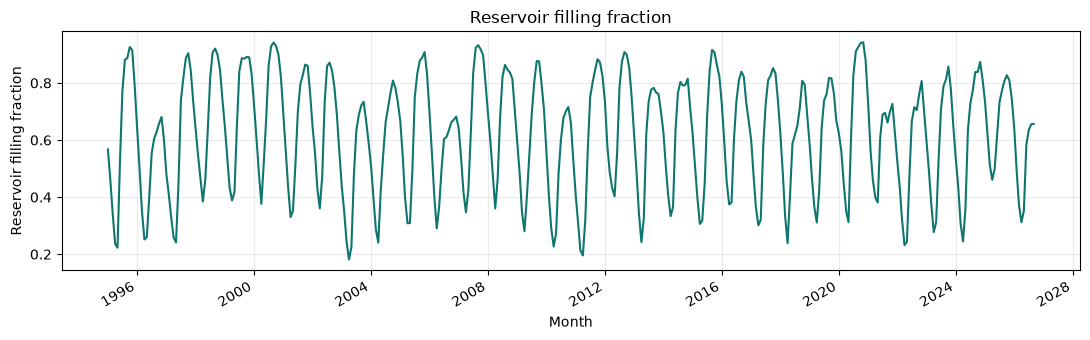

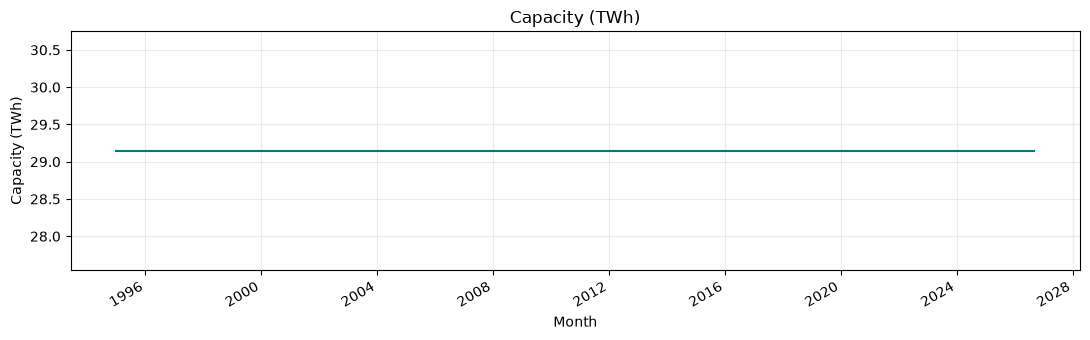

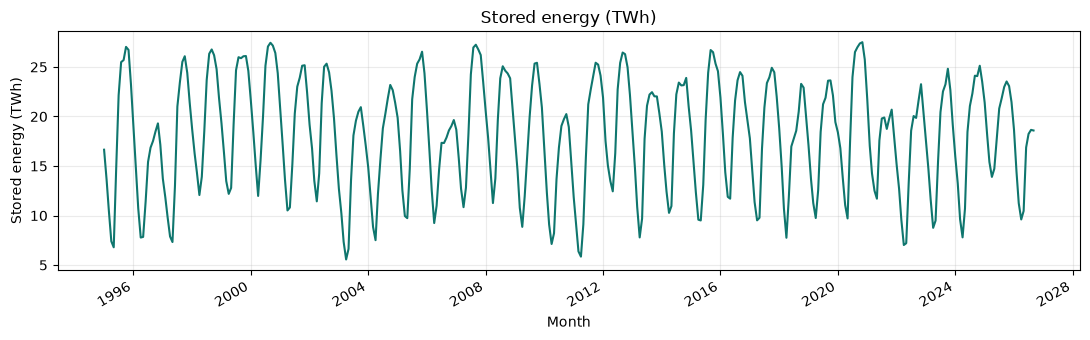

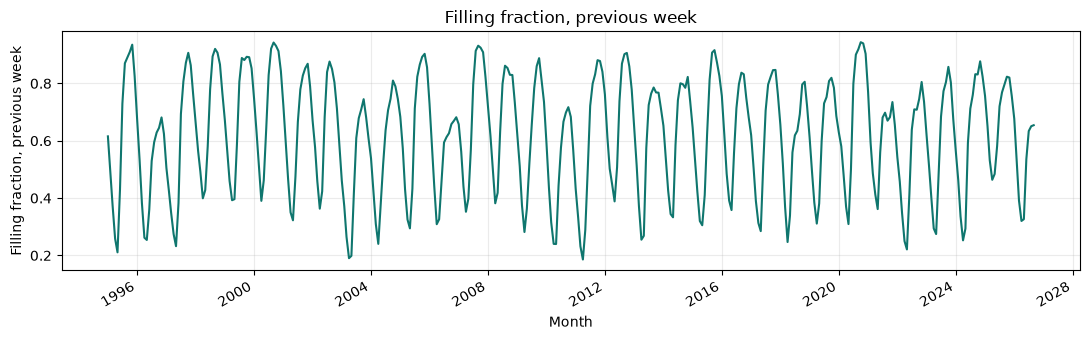

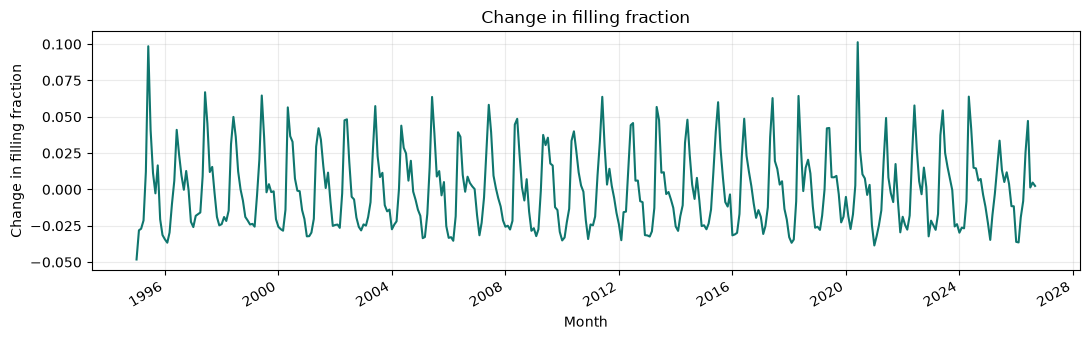

In [5]:
display_names = {
    'reservoir_filling_fraction': 'Reservoir filling fraction',
    'capacity_TWh': 'Capacity (TWh)',
    'stored_energy_TWh': 'Stored energy (TWh)',
    'filling_fraction_previous_week': 'Filling fraction, previous week',
    'change_in_filling_fraction': 'Change in filling fraction',
}

for column in measurement_columns:
    fig, ax = plt.subplots(figsize=(11, 3.5))
    ax.plot(monthly.index, monthly[column], color='#0f766e', linewidth=1.5)
    ax.set_title(display_names[column])
    ax.set_xlabel('Month')
    ax.set_ylabel(display_names[column])
    ax.grid(True, alpha=0.25)
    fig.autofmt_xdate()
    fig.tight_layout()
    plt.show()

## 6. Plot all measurements together

The measurement variables do not share the same units. I therefore apply min–max scaling to each monthly series. Each series is transformed to the interval 0–1, which allows the relative development to be compared in one chart without pretending that TWh and fractions have the same unit.

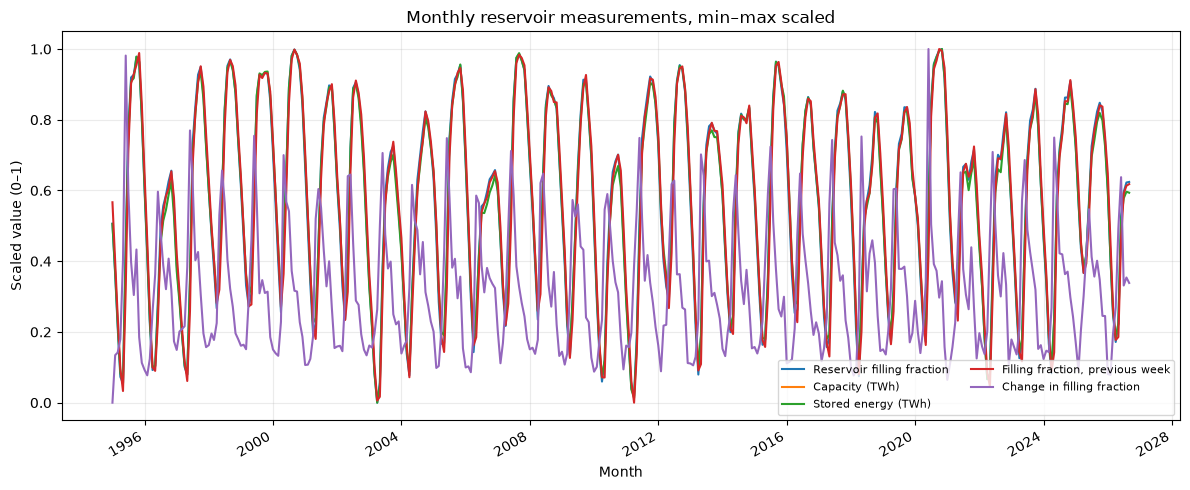

In [6]:
scaled = monthly.copy()
for column in scaled.columns:
    minimum = scaled[column].min()
    maximum = scaled[column].max()
    scaled[column] = (scaled[column] - minimum) / (maximum - minimum)

fig, ax = plt.subplots(figsize=(12, 5))
for column in scaled.columns:
    ax.plot(scaled.index, scaled[column], linewidth=1.5, label=display_names[column])
ax.set_title('Monthly reservoir measurements, min–max scaled')
ax.set_xlabel('Month')
ax.set_ylabel('Scaled value (0–1)')
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.25)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

## 7. AI usage

I used ChatGPT as a programming assistant to discuss the assignment requirements, suggest a clear project structure, explain Pandas and Streamlit syntax, and help check the code for reproducibility. I reviewed and adapted the suggestions, ran the code locally, and remain responsible for the final interpretation, plots and written submission.

## 8. Compulsory work log (draft, 300–500 words)

I started the compulsory work by reading reservoirs.csv with Pandas and checking the shape, data types and date range. The original headers were short Norwegian abbreviations, so I renamed them to English names that describe their content. I parsed the two date fields and sorted the observations by date. This made the dataset easier to inspect and meant that the same preparation could be reused in the Streamlit app.

The dataset contains weekly observations and several area-related records. Plotting every raw row directly would make the figure difficult to read because several observations can belong to the same date. I therefore created monthly means for the five measurement variables. I plotted every measurement separately first. This was useful because filling fractions and energy values have different scales. For the combined plot, I used min–max scaling from 0 to 1. The combined plot is consequently useful for comparing patterns and changes over time, while the separate plots preserve the original units.

I then created a Streamlit app with four pages. The home page explains the project and provides navigation. The data page presents one row for each imported column and uses LineChartColumn to show the observations belonging to the first calendar month for measurement columns. The plot page uses a dropdown to choose either one measurement or all measurements, and a select_slider to choose how far through the monthly series the chart should display. The CSV read is cached so that changing the controls does not repeatedly load the file. An About page documents the purpose and planned database extension.

The main practical lesson was that a notebook and an app serve different purposes. The notebook is better for transparent step-by-step analysis and documenting decisions, while Streamlit is better for presenting an interactive result. I used AI to clarify syntax and review the structure, but I checked the code and adapted it to the actual dataset.
